<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum07"

In [14]:
# Import Library
import pandas as pd                    # Untuk mengolah data dalam bentuk tabel (DataFrame)
import numpy as np                     # Untuk operasi numerik seperti array dan perhitungan matematika
import matplotlib.pyplot as plt        # Untuk membuat grafik visualisasi data
import seaborn as sns                  # Untuk membuat visualisasi data yang lebih menarik dan informatif
from sklearn.model_selection import train_test_split   # Untuk membagi dataset menjadi data training dan testing
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Untuk menstandarkan data numerik dan mengubah data kategorikal jadi numerik
from sklearn.ensemble import RandomForestRegressor      # Model Machine Learning tipe regresi berbasis kumpulan pohon keputusan (Random Forest)
from sklearn.linear_model import LinearRegression       # Model Machine Learning tipe regresi linear (hubungan linier antara variabel)
from sklearn.metrics import mean_squared_error, r2_score  # Untuk mengukur seberapa baik model memprediksi data (evaluasi model)

In [7]:
# 2️⃣ Load Dataset
df = pd.read_csv(path + "/data/dataset_satelit.csv", sep=',', encoding='latin-1')
print("🔹 Jumlah data:", df.shape)
df.head()

🔹 Jumlah data: (594, 34)


,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [8]:
df

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,590,103.605867,0.057633,2.49,0.16,0.347,0.78,0.86,63.38,269.95,...,0.2336,0.13050,0.09390,0.12700,0.09860,0.02600,0.00870,0.01690,0.00930,0.01630
590,591,103.606717,0.057100,2.74,0.15,0.466,0.73,0.5,51.04,683.42,...,0.2506,0.21280,0.15920,0.20060,0.14730,0.03870,0.01380,0.02290,0.01270,0.01640
591,592,103.606250,0.056767,2.63,0.15,0.422,0.82,0.59,82.57,396.18,...,0.3413,0.27730,0.17820,0.25790,0.18690,0.04620,0.01250,0.02250,0.01600,0.01930
592,593,103.606400,0.056517,2.75,0.17,0.502,0.69,0.53,102.07,246.35,...,0.3413,0.32740,0.28760,0.29970,0.22250,0.05290,0.01800,0.03350,0.01790,0.01930


In [9]:
# Menampilkan daftar nama kolom (header) dari dataset 'df'
print(df.columns)

Index(['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh'],
      dtype='object')


In [10]:
print("\n🔍 Informasi Dataset:")
print(df.info())

print("\n📊 Statistik Deskriptif:")
display(df.describe())

# Mengecek jumlah data kosong (missing value) pada tiap kolom
print("\n❗ Missing Values per Kolom:")
print(df.isnull().sum())

# Mengonversi kolom Mg ke numerik, Jika ada data tidak bisa dikonversi → diubah jadi NaN
df['Mg'] = pd.to_numeric(df['Mg'], errors='coerce')

# Mengisi nilai kosong pada K dan Mg dengan nilai rata-rata kolom masing-masing
df['K'].fillna(df['K'].mean(), inplace=True)
df['Mg'].fillna(df['Mg'].mean(), inplace=True)

# Mengecek kembali apakah masih ada missing value
print("\n❗ Missing Values after handling:")
print(df.isnull().sum())


🔍 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null    f

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620



❗ Missing Values per Kolom:
No           0
Longitude    0
Lattitude    0
N            0
P            0
K            1
Ca           0
Mg           0
Fe           0
Mn           0
Cu           0
Zn           0
B            0
b12          0
b11          0
b9           0
b8a          0
b8           0
b7           0
b6           0
b5           0
b4           0
b3           0
b2           0
b1           0
Sigma_VV     0
Sigma_VH     0
plia         0
lia          0
iafe         0
gamma0_vv    0
gamma0_vh    0
beta0_vv     0
beta0_vh     0
dtype: int64

❗ Missing Values after handling:
No           0
Longitude    0
Lattitude    0
N            0
P            0
K            0
Ca           0
Mg           0
Fe           0
Mn           0
Cu           0
Zn           0
B            0
b12          0
b11          0
b9           0
b8a          0
b8           0
b7           0
b6           0
b5           0
b4           0
b3           0
b2           0
b1           0
Sigma_VV     0
Sigma_VH     0
plia     

/tmp/ipython-input-3802440194.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['K'].fillna(df['K'].mean(), inplace=True)
/tmp/ipython-input-3802440194.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

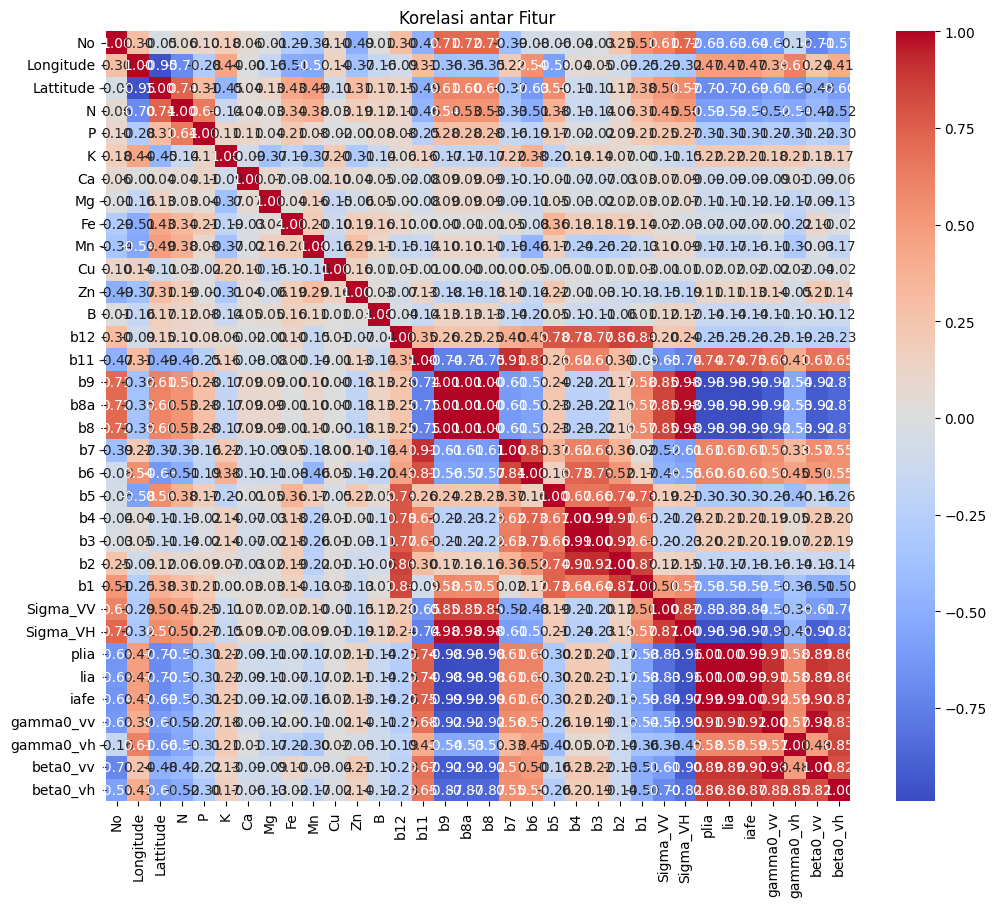

In [11]:
# Visualisasi korelasi antar kolom numerik
# Mengatur ukuran kanvas plot menjadi 12x10 inci, agar semua kolom terlihat jelas di heatmap
plt.figure(figsize=(12, 10))
# Menghitung korelasi antar kolom numerik di dataset
# Menampilkan hasil korelasi dalam bentuk heatmap (peta warna)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi antar Fitur")
plt.show()

In [12]:
# Menentukan kolom fitur (input) yang digunakan untuk melatih model
feature_cols = [ 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh']
# Menentukan kolom target/output yang ingin diprediksi (Nitrogen)
target_col = 'N'

# Memisahkan data fitur (X) dan target (y)
X = df[feature_cols] # Data Input
y = df[target_col]   # Data Output

# Melakukan standarisasi agar setiap fitur memiliki skala yang sama
# Inisialisasi StandardScaler
scaler = StandardScaler()
# Mengubah data X menjadi data yang sudah distandarkan
X_scaled = scaler.fit_transform(X)

In [15]:
# Membagi dataset menjadi data training dan data testing
# test_size=0.2 berarti 20% data digunakan untuk pengujian, 80% untuk pelatihan
# random_state=42 digunakan agar hasil pembagian data tetap sama setiap kali dijalankan
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Membuat model regresi linear
model = LinearRegression()
# Melatih model menggunakan data training
# Model akan belajar hubungan antara fitur (X_train) dan target (y_train)
model.fit(X_train, y_train)

LinearRegression()

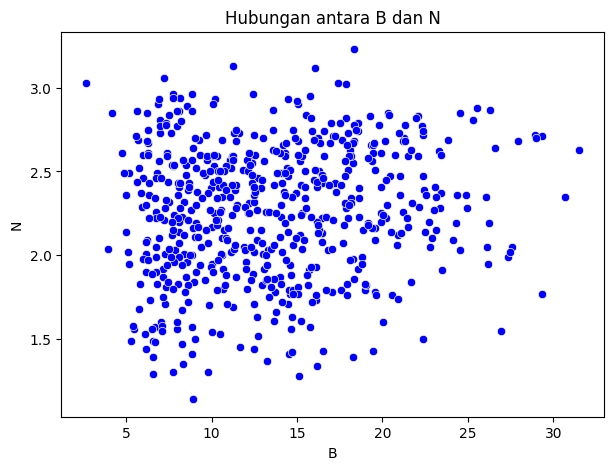

In [18]:
# Membuat ukuran kanvas plot dengan lebar 7 dan tinggi 5
plt.figure(figsize=(7, 5))
# Membuat scatter plot untuk melihat hubungan antara unsur B (Boron) dan N (Nitrogen)
sns.scatterplot(x=df['B'], y=df['N'], color='blue')
# Memberi judul pada grafik
plt.title("Hubungan antara B dan N")
# Memberi label pada sumbu X dan Y
plt.xlabel("B")
plt.ylabel("N")
# Menampilkan grafik
plt.show()

# Menggunakan model regresi linear untuk memprediksi nilai N berdasarkan data uji (X_test)
y_pred = model.predict(X_test)

📉 Mean Squared Error (MSE): 0.0674
📈 R² Score: 0.5550


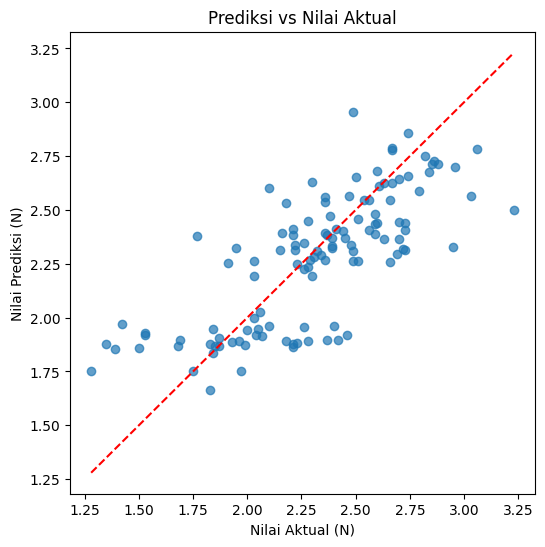

In [19]:
# Menghitung nilai error (MSE) antara hasil prediksi dan nilai sebenarnya
mse = mean_squared_error(y_test, y_pred)
# Menghitung nilai R² Score untuk melihat seberapa baik model menjelaskan data
r2 = r2_score(y_test, y_pred)
# Menampilkan hasil evaluasi model
# Semakin kecil MSE, semakin baik akurasi model
print(f"📉 Mean Squared Error (MSE): {mse:.4f}")
# Nilai R² mendekati 1 berarti model sangat baik
print(f"📈 R² Score: {r2:.4f}")

# Plot hasil prediksi vs nilai sebenarnya
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Nilai Aktual (N)")
plt.ylabel("Nilai Prediksi (N)")
plt.title("Prediksi vs Nilai Aktual")

# Membuat garis diagonal merah putus-putus untuk membandingkan kesesuaian
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()D

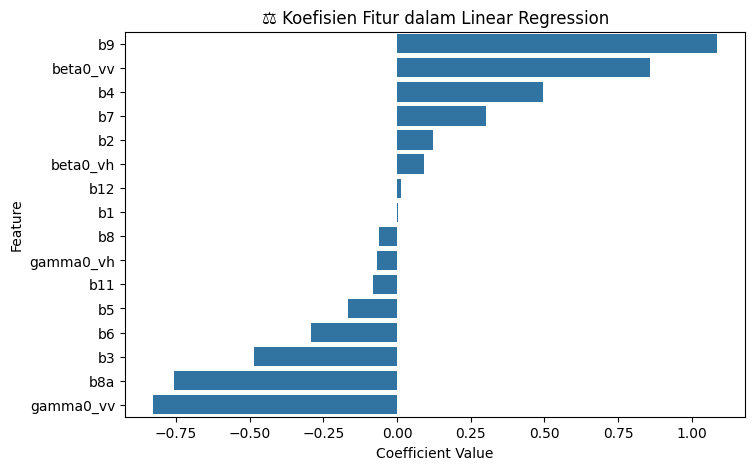


📊 Interpretasi:
- b9: pengaruh positif terhadap target (nilai = 1.086)
- beta0_vv: pengaruh positif terhadap target (nilai = 0.859)
- b4: pengaruh positif terhadap target (nilai = 0.495)
- b7: pengaruh positif terhadap target (nilai = 0.302)
- b2: pengaruh positif terhadap target (nilai = 0.121)
- beta0_vh: pengaruh positif terhadap target (nilai = 0.093)
- b12: pengaruh positif terhadap target (nilai = 0.013)
- b1: pengaruh positif terhadap target (nilai = 0.003)
- b8: pengaruh negatif terhadap target (nilai = -0.062)
- gamma0_vh: pengaruh negatif terhadap target (nilai = -0.066)
- b11: pengaruh negatif terhadap target (nilai = -0.082)
- b5: pengaruh negatif terhadap target (nilai = -0.166)
- b6: pengaruh negatif terhadap target (nilai = -0.291)
- b3: pengaruh negatif terhadap target (nilai = -0.486)
- b8a: pengaruh negatif terhadap target (nilai = -0.757)
- gamma0_vv: pengaruh negatif terhadap target (nilai = -0.827)


In [20]:
# Mengambil nilai koefisien dari model regresi linear
coef = model.coef_
# Membuat Series untuk menampilkan nilai koefisien tiap fitur dan mengurutkannya dari yang terbesar
feat_imp = pd.Series(coef, index=feature_cols).sort_values(ascending=False)

# Membuat grafik batang untuk melihat besar pengaruh masing-masing fitur terhadap target
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("⚖️ Koefisien Fitur dalam Linear Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

# Menampilkan interpretasi arah pengaruh tiap fitur terhadap target
print("\n📊 Interpretasi:")
for feature, value in feat_imp.items():
    # Cek arah pengaruh
    arah = "positif" if value > 0 else "negatif"
    print(f"- {feature}: pengaruh {arah} terhadap target (nilai = {value:.3f})")

In [21]:
# Menampilkan kesimpulan awal hasil pelatihan model
print("\n📊 Kesimpulan Awal:")
# Menampilkan jumlah dan daftar fitur yang digunakan dalam pelatihan model
print(f"- Model menggunakan {len(feature_cols)} fitur: {', '.join(feature_cols)}")
# Menampilkan kolom target yang ingin diprediksi, yaitu 'N'
print(f"- Target yang diprediksi: {target_col}")
# Menampilkan nilai R² (koefisien determinasi) untuk mengukur akurasi model
print(f"- Akurasi model (R²): {r2:.3f}")
# Menampilkan fitur dengan koefisien paling besar (pengaruh paling kuat terhadap target)
print(f"- Fitur paling berpengaruh: {feat_imp.index[0]} ({feat_imp.values[0]:.3f})")


📊 Kesimpulan Awal:
- Model menggunakan 16 fitur: b12, b11, b9, b8a, b8, b7, b6, b5, b4, b3, b2, b1, gamma0_vv, gamma0_vh, beta0_vv, beta0_vh
- Target yang diprediksi: N
- Akurasi model (R²): 0.555
- Fitur paling berpengaruh: b9 (1.086)
